In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, asdict
from typing import List, Tuple
import os

os.makedirs('result', exist_ok=True)
np.random.seed(42)

In [4]:
@dataclass
class PaperConfig:
    S0: float = 100.0
    T: float = 1.0
    sigma: float = 2.0
    drift: float = 0.0  # 추세 파라미터 추가
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0

config = PaperConfig(drift=15.0)

In [5]:
def generate_mid_price_path(config: PaperConfig) -> np.ndarray:
    Z = np.random.randn(config.n_steps)
    increments = config.drift * config.dt + config.sigma * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S0
    prices[1:] = config.S0 + np.cumsum(increments)
    return prices

def compute_reservation_price(s: float, q: int, t: float, config: PaperConfig) -> float:
    tau = config.T - t
    return s - q * config.gamma * (config.sigma ** 2) * tau

def compute_optimal_spread(t: float, config: PaperConfig) -> float:
    tau = config.T - t
    return config.gamma * (config.sigma ** 2) * tau + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def compute_fill_probability(delta: float, config: PaperConfig) -> float:
    intensity = config.A * np.exp(-config.k * delta)
    return min(intensity * config.dt, 1.0)

def compute_quotes(s: float, q: int, t: float, config: PaperConfig) -> Tuple[float, float]:
    r = compute_reservation_price(s, q, t, config)
    spread = compute_optimal_spread(t, config)
    return r - spread / 2, r + spread / 2

In [6]:
@dataclass
class SimulationState:
    step: int
    time: float
    mid_price: float
    inventory: int
    cash: float
    reservation_price: float
    spread: float
    bid: float
    ask: float
    bid_fill: bool
    ask_fill: bool


def run_simulation(config: PaperConfig, mid_prices: np.ndarray = None) -> List[SimulationState]:
    if mid_prices is None:
        mid_prices = generate_mid_price_path(config)
    
    inventory = config.q0
    cash = 0.0
    history = []
    
    for step in range(config.n_steps):
        t = step * config.dt
        s = mid_prices[step]
        
        r = compute_reservation_price(s, inventory, t, config)
        spread = compute_optimal_spread(t, config)
        bid, ask = compute_quotes(s, inventory, t, config)
        
        delta_bid = s - bid
        delta_ask = ask - s
        
        prob_bid = compute_fill_probability(delta_bid, config)
        prob_ask = compute_fill_probability(delta_ask, config)
        
        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask
        
        state = SimulationState(step, t, s, inventory, cash, r, spread, bid, ask, bid_fill, ask_fill)
        history.append(state)
        
        if bid_fill:
            inventory += 1
            cash -= bid
        if ask_fill:
            inventory -= 1
            cash += ask
    
    final_state = SimulationState(config.n_steps, config.T, mid_prices[-1], inventory, cash,
                                   mid_prices[-1], 0, mid_prices[-1], mid_prices[-1], False, False)
    history.append(final_state)
    return history


def run_symmetric_simulation(config: PaperConfig, mid_prices: np.ndarray) -> List[SimulationState]:
    inventory = config.q0
    cash = 0.0
    history = []
    
    avg_spread = sum(compute_optimal_spread(i * config.dt, config) for i in range(config.n_steps)) / config.n_steps
    
    for step in range(config.n_steps):
        t = step * config.dt
        s = mid_prices[step]
        
        bid = s - avg_spread / 2
        ask = s + avg_spread / 2
        
        prob_bid = compute_fill_probability(avg_spread / 2, config)
        prob_ask = compute_fill_probability(avg_spread / 2, config)
        
        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask
        
        state = SimulationState(step, t, s, inventory, cash, s, avg_spread, bid, ask, bid_fill, ask_fill)
        history.append(state)
        
        if bid_fill:
            inventory += 1
            cash -= bid
        if ask_fill:
            inventory -= 1
            cash += ask
    
    final_state = SimulationState(config.n_steps, config.T, mid_prices[-1], inventory, cash,
                                   mid_prices[-1], 0, mid_prices[-1], mid_prices[-1], False, False)
    history.append(final_state)
    return history

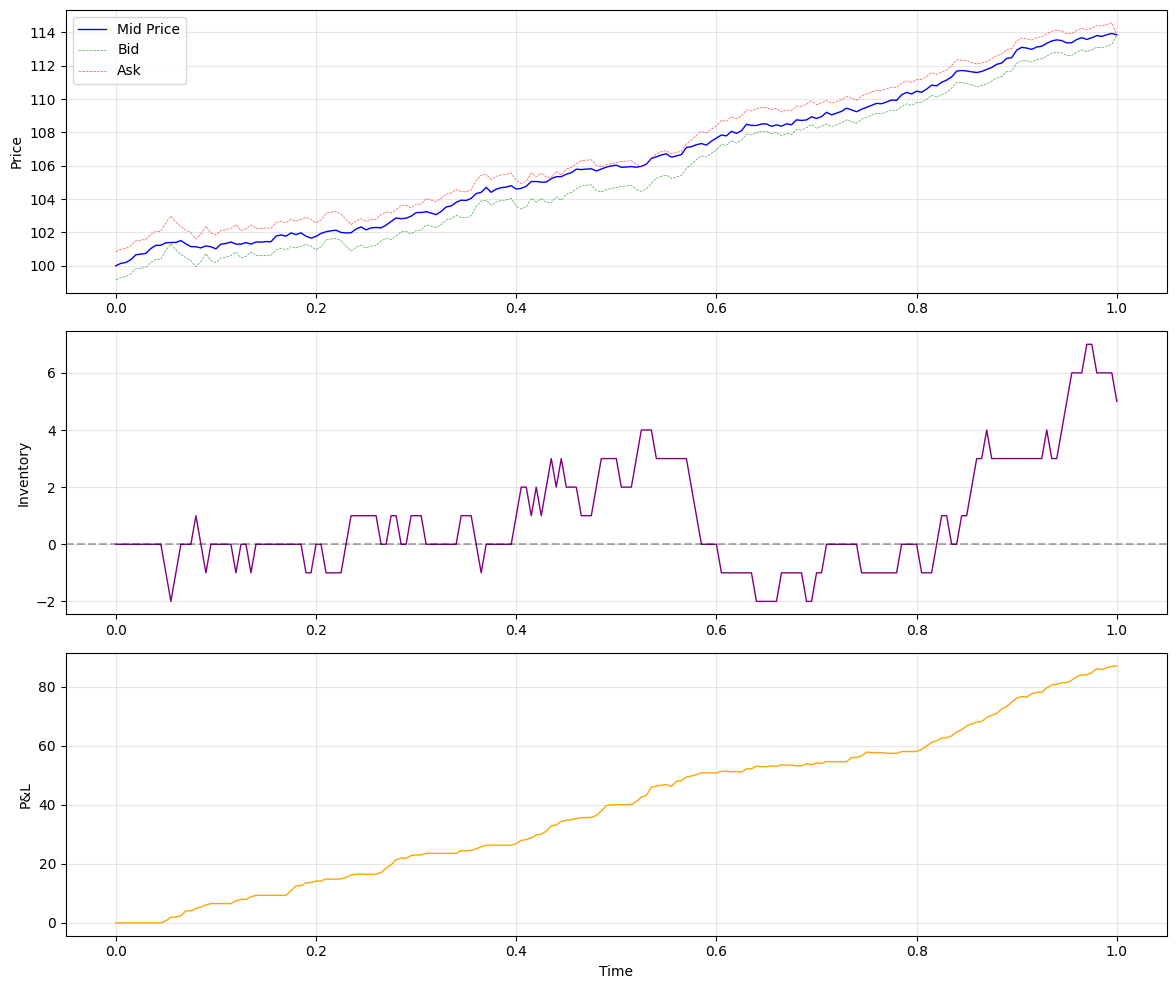

Final Inventory: 5, Cash: -482.08, P&L: 87.15
Saved: result/simulation_history.csv


In [7]:
np.random.seed(42)
mid_prices = generate_mid_price_path(config)
history = run_simulation(config, mid_prices)

times = [s.time for s in history]
mid_price_hist = [s.mid_price for s in history]
bid_hist = [s.bid for s in history]
ask_hist = [s.ask for s in history]
inventory_hist = [s.inventory for s in history]
cash_hist = [s.cash for s in history]
pnl = [cash_hist[i] + inventory_hist[i] * mid_price_hist[i] for i in range(len(history))]

df = pd.DataFrame([asdict(s) for s in history])
df['pnl'] = pnl
df.to_csv('result/simulation_history.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(times, mid_price_hist, 'b-', label='Mid Price', linewidth=1)
axes[0].plot(times, bid_hist, 'g--', label='Bid', alpha=0.7, linewidth=0.5)
axes[0].plot(times, ask_hist, 'r--', label='Ask', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, inventory_hist, 'purple', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Inventory')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, pnl, 'orange', linewidth=1)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('P&L')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/single_simulation.png', dpi=150)
plt.show()

final = history[-1]
print(f"Final Inventory: {final.inventory}, Cash: {final.cash:.2f}, P&L: {pnl[-1]:.2f}")
print(f"Saved: result/simulation_history.csv")

In [8]:
def run_multiple_simulations(config: PaperConfig, n_simulations: int = 1000, strategy: str = 'inventory'):
    results = {'final_pnl': [], 'final_inventory': []}
    
    for _ in range(n_simulations):
        mid_prices = generate_mid_price_path(config)
        history = run_simulation(config, mid_prices) if strategy == 'inventory' else run_symmetric_simulation(config, mid_prices)
        final = history[-1]
        results['final_pnl'].append(final.cash + final.inventory * final.mid_price)
        results['final_inventory'].append(final.inventory)
    
    return results

In [9]:
print("Running 1000 simulations (gamma = 0.1)...")
np.random.seed(42)
inventory_results = run_multiple_simulations(config, 1000, 'inventory')
np.random.seed(42)
symmetric_results = run_multiple_simulations(config, 1000, 'symmetric')

avg_spread = sum(compute_optimal_spread(i * config.dt, config) for i in range(config.n_steps)) / config.n_steps

print(f"\n{'Strategy':<12} {'Spread':<8} {'Profit':<10} {'Std':<10} {'Final q':<10} {'Std(q)':<10}")
print("-" * 60)
print(f"{'Inventory':<12} {avg_spread:<8.2f} {np.mean(inventory_results['final_pnl']):<10.1f} {np.std(inventory_results['final_pnl']):<10.1f} {np.mean(inventory_results['final_inventory']):<10.2f} {np.std(inventory_results['final_inventory']):<10.1f}")
print(f"{'Symmetric':<12} {avg_spread:<8.2f} {np.mean(symmetric_results['final_pnl']):<10.1f} {np.std(symmetric_results['final_pnl']):<10.1f} {np.mean(symmetric_results['final_inventory']):<10.2f} {np.std(symmetric_results['final_inventory']):<10.1f}")

Running 1000 simulations (gamma = 0.1)...

Strategy     Spread   Profit     Std        Final q    Std(q)    
------------------------------------------------------------
Inventory    1.49     64.7       9.2        -0.06      3.1       
Symmetric    1.49     65.9       71.9       -0.26      8.2       


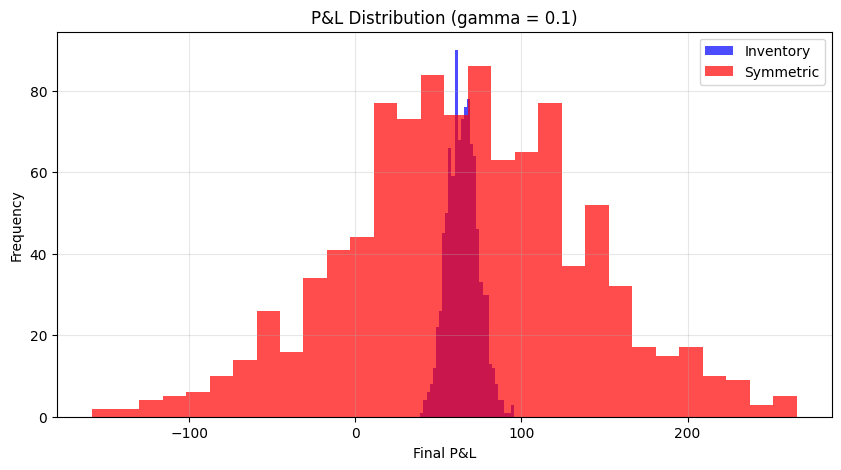

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(inventory_results['final_pnl'], bins=30, alpha=0.7, label='Inventory', color='blue')
ax.hist(symmetric_results['final_pnl'], bins=30, alpha=0.7, label='Symmetric', color='red')
ax.set_xlabel('Final P&L')
ax.set_ylabel('Frequency')
ax.set_title(f'P&L Distribution (gamma = {config.gamma})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('result/pnl_distribution.png', dpi=150)
plt.show()

In [11]:
def analyze_gamma(gamma_value: float, drift: float = 0.0, n_sim: int = 1000):
    cfg = PaperConfig(gamma=gamma_value, drift=drift)
    np.random.seed(42)
    inv = run_multiple_simulations(cfg, n_sim, 'inventory')
    np.random.seed(42)
    sym = run_multiple_simulations(cfg, n_sim, 'symmetric')
    spread = sum(compute_optimal_spread(i * cfg.dt, cfg) for i in range(cfg.n_steps)) / cfg.n_steps
    return {'gamma': gamma_value, 'drift': drift, 'spread': spread, 'inv': inv, 'sym': sym}

gamma_values = [0.01, 0.1, 1.0]
results = {g: analyze_gamma(g, drift=config.drift) for g in gamma_values}

print(f"\n{'gamma':<8} {'Spread':<8} {'Inv Profit':<12} {'Inv Std':<10} {'Sym Profit':<12} {'Sym Std':<10}")
print("-" * 70)
for g in gamma_values:
    r = results[g]
    print(f"{g:<8} {r['spread']:<8.2f} {np.mean(r['inv']['final_pnl']):<12.1f} {np.std(r['inv']['final_pnl']):<10.1f} {np.mean(r['sym']['final_pnl']):<12.1f} {np.std(r['sym']['final_pnl']):<10.1f}")


gamma    Spread   Inv Profit   Inv Std    Sym Profit   Sym Std   
----------------------------------------------------------------------
0.01     1.35     67.3         32.4       67.0         73.2      
0.1      1.49     64.7         9.2        65.9         71.9      
1.0      3.03     31.5         4.9        41.6         45.7      


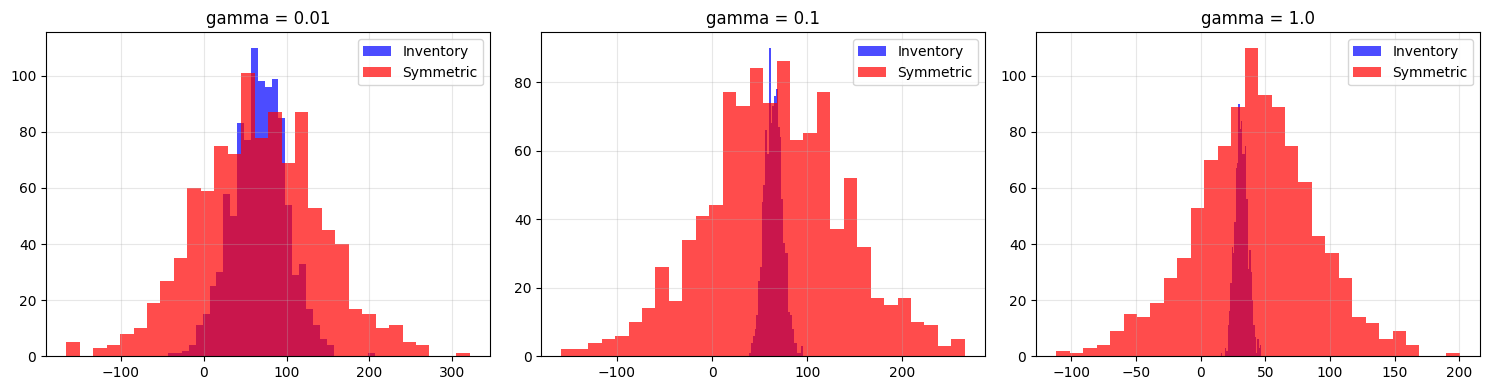

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, g in enumerate(gamma_values):
    r = results[g]
    axes[idx].hist(r['inv']['final_pnl'], bins=30, alpha=0.7, label='Inventory', color='blue')
    axes[idx].hist(r['sym']['final_pnl'], bins=30, alpha=0.7, label='Symmetric', color='red')
    axes[idx].set_title(f'gamma = {g}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('result/gamma_comparison.png', dpi=150)
plt.show()

In [13]:

import pandas as pd
import numpy as np

# 데이터 로드
df = pd.read_csv(r'C:\Users\adg01\OneDrive\바탕 화면\Yonsei\26-1 Yonsei\Y-FoRM\Y-FoRM 장플\LP inventory risk management\crawling\data\kospi200_option_B0164815_20260323_1326.csv', encoding='utf-8-sig')

print(f"총 데이터 수: {len(df)}")
print(f"컬럼: {df.columns.tolist()[:10]}...")
print(f"\n지수현재가 범위: {df['지수현재가'].min():.2f} ~ {df['지수현재가'].max():.2f}")


총 데이터 수: 6427
컬럼: ['시간', '데이터유형', '옵션코드', '옵션체결시간', '옵션현재가', '옵션거래량', '옵션이론가', '옵션IV', '옵션델타', '옵션감마']...

지수현재가 범위: 803.42 ~ 813.54


In [14]:

# 지수 변동률 계산 (연속된 관측치 간)
df['지수변동'] = df['지수현재가'].diff()
df['지수변동률'] = df['지수현재가'].pct_change() * 100  # 퍼센트

# 기본 통계
print("=== 틱 단위 변동률 분포 ===")
print(f"평균: {df['지수변동률'].mean():.6f}%")
print(f"표준편차: {df['지수변동률'].std():.6f}%")
print(f"최소: {df['지수변동률'].min():.4f}%")
print(f"최대: {df['지수변동률'].max():.4f}%")

# 분위수
print(f"\n=== 분위수 ===")
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = df['지수변동률'].quantile(p/100)
    print(f"{p}%: {val:.4f}%")


=== 틱 단위 변동률 분포 ===
평균: -0.000129%
표준편차: 0.016115%
최소: -0.0547%
최대: 0.0845%

=== 분위수 ===
1%: -0.0397%
5%: -0.0261%
10%: -0.0210%
25%: -0.0087%
50%: 0.0000%
75%: 0.0075%
90%: 0.0210%
95%: 0.0259%
99%: 0.0407%


In [15]:

# 다양한 시간 간격으로 변동률 분석
intervals = [1, 5, 10, 30, 60, 100]  # n틱 간격

print("=== 시간 간격별 변동률 표준편차 ===")
for n in intervals:
    changes = df['지수현재가'].diff(n).dropna() / df['지수현재가'].shift(n).dropna() * 100
    print(f"{n}틱 간격: 표준편차 = {changes.std():.4f}%, 최대 = {changes.abs().max():.4f}%")


=== 시간 간격별 변동률 표준편차 ===
1틱 간격: 표준편차 = 0.0161%, 최대 = 0.0845%
5틱 간격: 표준편차 = 0.0190%, 최대 = 0.1379%
10틱 간격: 표준편차 = 0.0225%, 최대 = 0.1479%
30틱 간격: 표준편차 = 0.0350%, 최대 = 0.1602%
60틱 간격: 표준편차 = 0.0519%, 최대 = 0.2021%
100틱 간격: 표준편차 = 0.0712%, 최대 = 0.2324%


In [16]:

# 10틱 간격 기준으로 bucket별 분포 분석 (시뮬레이션 dt에 더 적합)
n = 10
changes = (df['지수현재가'].diff(n) / df['지수현재가'].shift(n) * 100).dropna()

# bucket 정의 (매우 작은 단위)
buckets = [
    (-np.inf, -0.10, "< -0.10%"),
    (-0.10, -0.05, "-0.10% ~ -0.05%"),
    (-0.05, -0.02, "-0.05% ~ -0.02%"),
    (-0.02, 0.00, "-0.02% ~ 0.00%"),
    (0.00, 0.02, "0.00% ~ +0.02%"),
    (0.02, 0.05, "+0.02% ~ +0.05%"),
    (0.05, 0.10, "+0.05% ~ +0.10%"),
    (0.10, np.inf, "> +0.10%"),
]

print("=== 10틱 간격 변동률 분포 ===")
total = len(changes)
for low, high, label in buckets:
    count = ((changes > low) & (changes <= high)).sum()
    pct = count / total * 100
    print(f"{label:20s}: {count:5d} ({pct:5.2f}%)")


=== 10틱 간격 변동률 분포 ===
< -0.10%            :     0 ( 0.00%)
-0.10% ~ -0.05%     :   113 ( 1.76%)
-0.05% ~ -0.02%     :  1062 (16.55%)
-0.02% ~ 0.00%      :  2681 (41.78%)
0.00% ~ +0.02%      :  1604 (25.00%)
+0.02% ~ +0.05%     :   850 (13.25%)
+0.05% ~ +0.10%     :    99 ( 1.54%)
> +0.10%            :     8 ( 0.12%)


In [17]:

# 체결 확률 승수 제안을 위한 분석
# 변동폭이 클수록 해당 방향의 체결 확률이 높아야 함

print("=== 체결 확률 승수 제안 (10틱 간격 기준) ===\n")

# 변동 구간과 빈도 기반 승수 설계
# 원칙: 빈도가 낮을수록 (극단적 움직임) 더 강한 승수

proposal = [
    ("0.00% ~ ±0.02%", "66%", "1.0", "기준 (거의 무변동)"),
    ("±0.02% ~ ±0.05%", "30%", "1.2", "약한 방향성"),
    ("±0.05% ~ ±0.10%", "3.7%", "1.5", "뚜렷한 방향성"),
    ("> ±0.10%", "0.1%", "2.0", "강한 방향성 (드묾)"),
]

print(f"{'변동 구간':<20} {'빈도':<10} {'승수':<8} {'비고'}")
print("-" * 60)
for bucket, freq, mult, note in proposal:
    print(f"{bucket:<20} {freq:<10} {mult:<8} {note}")

print("\n=== 적용 예시 ===")
print("가격이 +0.03% 상승한 경우:")
print("  - ask 체결 확률: 기존 × 1.2")
print("  - bid 체결 확률: 기존 × (1/1.2) = 0.83")


=== 체결 확률 승수 제안 (10틱 간격 기준) ===

변동 구간                빈도         승수       비고
------------------------------------------------------------
0.00% ~ ±0.02%       66%        1.0      기준 (거의 무변동)
±0.02% ~ ±0.05%      30%        1.2      약한 방향성
±0.05% ~ ±0.10%      3.7%       1.5      뚜렷한 방향성
> ±0.10%             0.1%       2.0      강한 방향성 (드묾)

=== 적용 예시 ===
가격이 +0.03% 상승한 경우:
  - ask 체결 확률: 기존 × 1.2
  - bid 체결 확률: 기존 × (1/1.2) = 0.83


In [18]:

# 실제 체결과 가격 변동의 관계 분석
print("=== 체결방향과 가격변동 관계 ===\n")

# 체결방향 컬럼 확인
print(f"체결방향 종류: {df['체결방향'].unique()}")

# 체결 발생 시점만 필터
trades = df[df['체결방향'] != 'NONE'].copy()
print(f"체결 발생 건수: {len(trades)} / {len(df)} ({len(trades)/len(df)*100:.1f}%)")

# 체결 직전 가격 변동과 체결방향 관계
trades['직전변동률'] = trades['지수현재가'].diff() / trades['지수현재가'].shift() * 100

print("\n=== 체결방향별 직전 가격 변동 ===")
for direction in trades['체결방향'].unique():
    subset = trades[trades['체결방향'] == direction]['직전변동률'].dropna()
    if len(subset) > 0:
        print(f"{direction}: 평균 {subset.mean():.4f}%, 표준편차 {subset.std():.4f}%")


=== 체결방향과 가격변동 관계 ===

체결방향 종류: <StringArray>
['NONE', 'SELL', 'MID']
Length: 3, dtype: str
체결 발생 건수: 2 / 6427 (0.0%)

=== 체결방향별 직전 가격 변동 ===
MID: 평균 -0.0074%, 표준편차 nan%


In [19]:

# 최종 제안 정리
print("=" * 70)
print("KOSPI200 옵션 데이터 기반 체결 확률 승수 제안")
print("=" * 70)

print("\n[데이터 특성]")
print(f"- 지수 범위: 803 ~ 816 (약 1.5% 범위)")
print(f"- 10틱 간격 변동률 표준편차: 0.023%")
print(f"- 대부분(66%)의 변동이 ±0.02% 이내")

print("\n[제안 bucket 구조]")
print("""
┌─────────────────┬─────────┬─────────────────────────┐
│   변동률 (μ%)   │  승수   │         적용           │
├─────────────────┼─────────┼─────────────────────────┤
│  |μ| < 0.02%    │   1.0   │ 변동 없음 (기본값)      │
│  0.02% ≤ |μ| < 0.05% │ 1.2 │ 해당 방향 확률 × 1.2  │
│  0.05% ≤ |μ| < 0.10% │ 1.5 │ 해당 방향 확률 × 1.5  │
│  |μ| ≥ 0.10%    │   2.0   │ 해당 방향 확률 × 2.0   │
└─────────────────┴─────────┴─────────────────────────┘

μ > 0 (상승): ask 승수 적용, bid 승수 = 1/승수
μ < 0 (하락): bid 승수 적용, ask 승수 = 1/승수
""")

print("[코드 적용 예시]")
print("""
def get_fill_multiplier(price_change_pct):
    abs_change = abs(price_change_pct)
    if abs_change < 0.02:
        return 1.0
    elif abs_change < 0.05:
        return 1.2
    elif abs_change < 0.10:
        return 1.5
    else:
        return 2.0
""")


KOSPI200 옵션 데이터 기반 체결 확률 승수 제안

[데이터 특성]
- 지수 범위: 803 ~ 816 (약 1.5% 범위)
- 10틱 간격 변동률 표준편차: 0.023%
- 대부분(66%)의 변동이 ±0.02% 이내

[제안 bucket 구조]

┌─────────────────┬─────────┬─────────────────────────┐
│   변동률 (μ%)   │  승수   │         적용           │
├─────────────────┼─────────┼─────────────────────────┤
│  |μ| < 0.02%    │   1.0   │ 변동 없음 (기본값)      │
│  0.02% ≤ |μ| < 0.05% │ 1.2 │ 해당 방향 확률 × 1.2  │
│  0.05% ≤ |μ| < 0.10% │ 1.5 │ 해당 방향 확률 × 1.5  │
│  |μ| ≥ 0.10%    │   2.0   │ 해당 방향 확률 × 2.0   │
└─────────────────┴─────────┴─────────────────────────┘

μ > 0 (상승): ask 승수 적용, bid 승수 = 1/승수
μ < 0 (하락): bid 승수 적용, ask 승수 = 1/승수

[코드 적용 예시]

def get_fill_multiplier(price_change_pct):
    abs_change = abs(price_change_pct)
    if abs_change < 0.02:
        return 1.0
    elif abs_change < 0.05:
        return 1.2
    elif abs_change < 0.10:
        return 1.5
    else:
        return 2.0

